# Sachs Convergence PDF: Perturbative Workflow

This notebook demonstrates the full workflow for computing perturbative corrections
to field moments using `sft-wick`, with numerical evaluation of the coupling coefficients
and propagators.

**Physical setup:**
- Three-component physical field $\phi_a(\mathbf{x})$ and response field $\psi_a(\mathbf{x})$, with $a \in \{1,2,3\}$
- Cubic interaction vertex: $S_{\mathrm{int}} = -F_{abc}\,\psi_a\,\phi_b\,\phi_c$ (summation over repeated indices)
- Propagators: matrix-valued $R_{ab}$ (retarded) and $C_{ab}$ (correlation), expressed via eigendecomposition

**Workflow:**
1. Symbolic expansion of moments $\langle\phi_1(x)\rangle$, $\langle\phi_1(x)\,\phi_1(x')\rangle$ using Wick's theorem
2. Extract Feynman diagrams and coupling coefficients as structured `DiagramTerm` objects
3. Substitute numerical $F$ tensor values to get numeric coupling arrays
4. Set up propagator matrices via eigendecomposition of the coupling matrix $M$

In [1]:
import numpy as np
from IPython.display import display, Math

from sft_wick import (
    Field, Vertex, Action, compute_moment, DiagramTerm,
    LaTeXFormatter, reset_uid_counter,
)

## 1. Field and Vertex Setup

Define the 3-component fields and the cubic interaction vertex.

**Convention note:** `sft-wick` defines the vertex as $S_{\mathrm{int}} = F_{abc}\,\psi_a\,\phi_b\,\phi_c$ (positive sign). Since the physical action has $S_{\mathrm{int}} = -F_{abc}\,\psi_a\,\phi_b\,\phi_c$, we absorb the minus sign into the coupling: when substituting numerical values, we use $F_{\mathrm{code}} = -F_{\mathrm{physical}}$.

In [2]:
# 3-component fields
phi = Field('phi', 'physical', n_components=3)
psi = Field('psi', 'response', n_components=3)

# Vertex: F_{abc} psi_a phi_b phi_c  (fields=[psi, phi, phi] so indices match user convention)
v = Vertex(fields=[psi, phi, phi], coupling='F')
action = Action(vertices=[v])

print(f"Vertex: {v}")
print(f"  Fields: {[f.name for f in v.fields]}")
print(f"  Coupling: {v.coupling}")

Vertex: Vertex(fields=(Field(name='psi', field_type=<FieldType.RESPONSE: 'response'>, n_components=3), Field(name='phi', field_type=<FieldType.PHYSICAL: 'physical'>, n_components=3), Field(name='phi', field_type=<FieldType.PHYSICAL: 'physical'>, n_components=3)), coupling='F', local=True)
  Fields: ['psi', 'phi', 'phi']
  Coupling: F


## 2. The Coupling Tensor $F$

Nonzero entries of $F_{abc}$ (1-indexed):

| $(a,b,c)$ | $F_{abc}$ |
|-----------|-----------|
| $(1,1,1)$ | $-1/2$    |
| $(1,2,2)$ | $-2$      |
| $(1,3,3)$ | $-2$      |
| $(2,1,2)$ | $-1$      |
| $(3,1,3)$ | $-1$      |

In [3]:
# Physical F tensor (0-indexed)
F_physical = np.zeros((3, 3, 3))
F_physical[0, 0, 0] = -0.5   # F_{111}
F_physical[0, 1, 1] = -2.0   # F_{122}
F_physical[0, 2, 2] = -2.0   # F_{133}
F_physical[1, 0, 1] = -1.0   # F_{212}
F_physical[2, 0, 2] = -1.0   # F_{313}

# Code coupling: negate to absorb the minus sign in S_int = -F psi phi phi
F_code = -F_physical

print("F_code nonzero entries:")
for idx in zip(*np.nonzero(F_code)):
    print(f"  F[{idx[0]+1},{idx[1]+1},{idx[2]+1}] = {F_code[idx]:+.1f}")

F_code nonzero entries:
  F[1,1,1] = +0.5
  F[1,2,2] = +2.0
  F[1,3,3] = +2.0
  F[2,1,2] = +1.0
  F[3,1,3] = +1.0


## 3. First Moment: $\langle \phi_1(x) \rangle$

Compute the perturbative expansion of $\langle \phi_1(x) \rangle_S$ up to order 3.

Odd orders vanish because the total number of field operators is odd.

In [4]:
reset_uid_counter()
obs_mean = [phi('1', 'x')]  # phi_1(x) — component index '1' is external (not summed)

result_mean = compute_moment(obs_mean, action, order=3, response_phase=False)

for n in range(4):
    latex = result_mean.order(n).to_latex()
    display(Math(rf"O({n}): \quad {latex}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

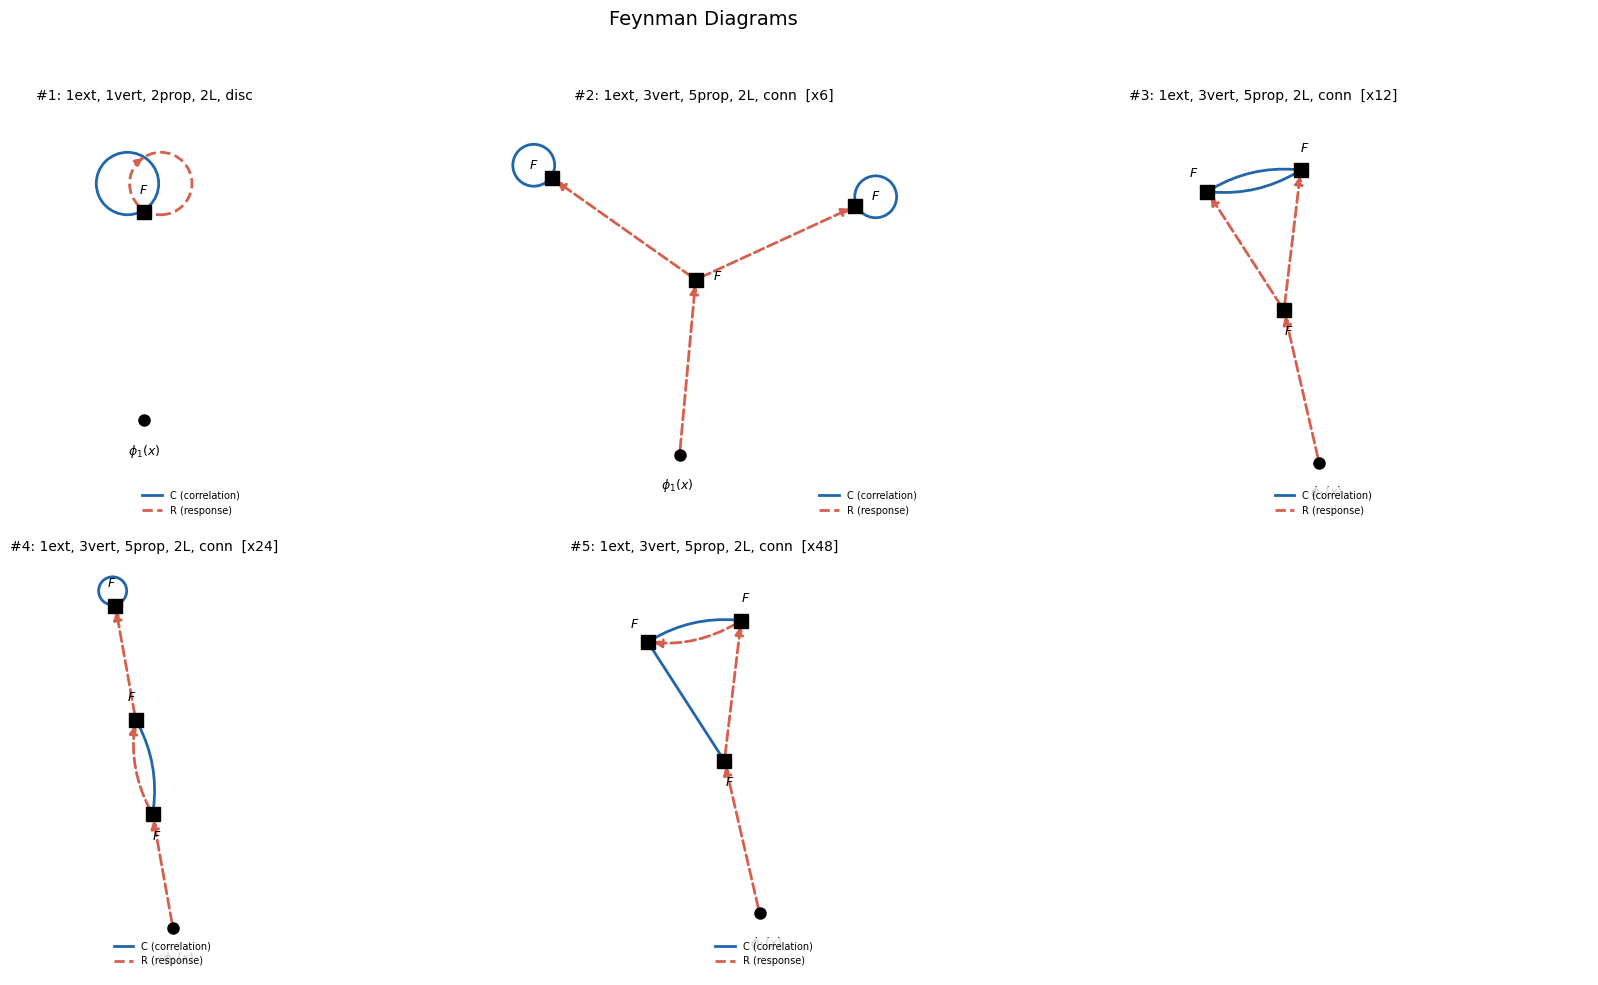

In [5]:
# Draw Feynman diagrams
result_mean.draw_diagrams()

## 4. DiagramTerm: Structured Output for Numerical Evaluation

Each `DiagramTerm` carries everything needed to evaluate a single Feynman diagram numerically:

| Attribute | Description |
|-----------|-------------|
| `propagators` | Tuple of propagators forming the diagram |
| `coupling_sum` | Symbolic coupling expression (sum of index permutations) |
| `rational_prefactor` | The $(-1)^n / n! \times$ multinomial coefficient |
| `integration_vars` | Spatial variables to integrate over |
| `summation_indices` | `(index_name, dimension)` pairs for component sums |
| `n_response` | Number of $R$ propagators (determines the MSR phase $(-i)^{n_R}$) |

In [6]:
# Inspect DiagramTerms at order 1 for <phi_1(x)>
print(f"Order 1: {len(result_mean.diagram_terms(1))} diagram(s)\n")

for i, dt in enumerate(result_mean.diagram_terms(1)):
    print(f"--- Diagram {i} ---")
    print(f"  Propagators:    {[p.to_latex() for p in dt.propagators]}")
    print(f"  Coupling sum:   {dt.coupling_sum.to_latex()}")
    print(f"  Prefactor:      {dt.rational_prefactor.numerator}/{dt.rational_prefactor.denominator}")
    print(f"  Integration:    {dt.integration_vars}")
    print(f"  Sum indices:    {dt.summation_indices}")
    print(f"  # R propagators: {dt.n_response}")
    print(f"  Phase (-i)^n_R: {dt.response_phase_factor()}")
    print(f"  Topology:       {dt.spatial_topology()}")
    print()

Order 1: 1 diagram(s)

--- Diagram 0 ---
  Propagators:    ['R_{1i_{0}}(x, y_{0})', 'C_{i_{1}i_{2}}(y_{0}, y_{0})']
  Coupling sum:   F_{i_{0}i_{1}i_{2}}
  Prefactor:      -1/1
  Integration:    ('y_0',)
  Sum indices:    (('i_0', 3), ('i_1', 3), ('i_2', 3))
  # R propagators: 1
  Phase (-i)^n_R: (-0-1j)
  Topology:       [('R', 'x', 'y_0'), ('C', 'y_0', 'y_0')]



### Numerical Coupling Evaluation

`evaluate_coupling()` substitutes the numeric $F$ tensor into the symbolic coupling expression and returns a NumPy array indexed by the summation indices, with the rational prefactor applied.

In [7]:
# Evaluate coupling numerically at order 1
for i, dt in enumerate(result_mean.diagram_terms(1)):
    coupling_array = dt.evaluate_coupling({'F': F_code})
    
    print(f"Diagram {i}: coupling array shape = {coupling_array.shape}")
    print(f"  Index names: {[name for name, _ in dt.summation_indices]}")
    print(f"  Nonzero entries:")
    for idx in zip(*np.nonzero(coupling_array)):
        label = ", ".join(f"{name}={v+1}" for (name, _), v in zip(dt.summation_indices, idx))
        print(f"    ({label}) = {coupling_array[idx]:+.4f}")
    print(f"  Total sum over indices: {np.sum(coupling_array):+.4f}")
    print()

Diagram 0: coupling array shape = (3, 3, 3)
  Index names: ['i_0', 'i_1', 'i_2']
  Nonzero entries:
    (i_0=1, i_1=1, i_2=1) = -0.5000
    (i_0=1, i_1=2, i_2=2) = -2.0000
    (i_0=1, i_1=3, i_2=3) = -2.0000
    (i_0=2, i_1=1, i_2=2) = -1.0000
    (i_0=3, i_1=1, i_2=3) = -1.0000
  Total sum over indices: -6.5000



## 5. Second Moment: $\langle \phi_1(x)\,\phi_1(x') \rangle$

At order 2, multiple Feynman diagrams appear with coupling permutation sums like $(F_{abc} F_{def} + F_{abc} F_{edf})$.

In [8]:
reset_uid_counter()
obs_corr = [phi('1', 'x'), phi('1', 'x_prime')]

result_corr = compute_moment(obs_corr, action, order=2, response_phase=False)

for n in range(3):
    latex = result_corr.order(n).to_latex()
    if len(latex) > 200:
        display(Math(rf"O({n}): \quad \text{{({len(latex)} chars, see below)}}"))
    else:
        display(Math(rf"O({n}): \quad {latex}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
# Order 2 diagram summary
dts = result_corr.diagram_terms(2)
print(f"Order 2: {len(dts)} distinct Feynman diagrams\n")

for i, dt in enumerate(dts):
    topo = dt.spatial_topology()
    kinds = [k for k, _, _ in topo]
    print(f"Diagram {i}:  {' '.join(p.to_latex() for p in dt.propagators)}")
    print(f"  Coupling:  {dt.coupling_sum.to_latex()}")
    print(f"  Prefactor: {dt.rational_prefactor.numerator}/{dt.rational_prefactor.denominator}")
    print()

Order 2: 11 distinct Feynman diagrams

Diagram 0:  R_{1i_{0}}(x, y_{0}) R_{1i_{3}}(x_{prime}, y_{1}) C_{i_{1}i_{2}}(y_{0}, y_{0}) C_{i_{4}i_{5}}(y_{1}, y_{1})
  Coupling:  F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} + F_{i_{3}i_{4}i_{5}} F_{i_{0}i_{1}i_{2}}
  Prefactor: 1/2

Diagram 1:  R_{1i_{0}}(x, y_{0}) R_{1i_{3}}(x_{prime}, y_{1}) C_{i_{1}i_{4}}(y_{0}, y_{1}) C_{i_{2}i_{5}}(y_{0}, y_{1})
  Coupling:  F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} + F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{5}i_{4}}
  Prefactor: 1/2

Diagram 2:  R_{1i_{0}}(x, y_{0}) R_{i_{1}i_{3}}(y_{0}, y_{1}) C_{1i_{2}}(x_{prime}, y_{0}) C_{i_{4}i_{5}}(y_{1}, y_{1})
  Coupling:  F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} + F_{i_{0}i_{2}i_{1}} F_{i_{3}i_{4}i_{5}}
  Prefactor: 1/2

Diagram 3:  R_{1i_{0}}(x, y_{0}) R_{i_{1}i_{3}}(y_{0}, y_{1}) C_{1i_{4}}(x_{prime}, y_{1}) C_{i_{2}i_{5}}(y_{0}, y_{1})
  Coupling:  F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} + F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{5}i_{4}} + F_{i_{0}i_{2}i_{1}} F_{i_{3}i_{4}i_{5}} + F_{

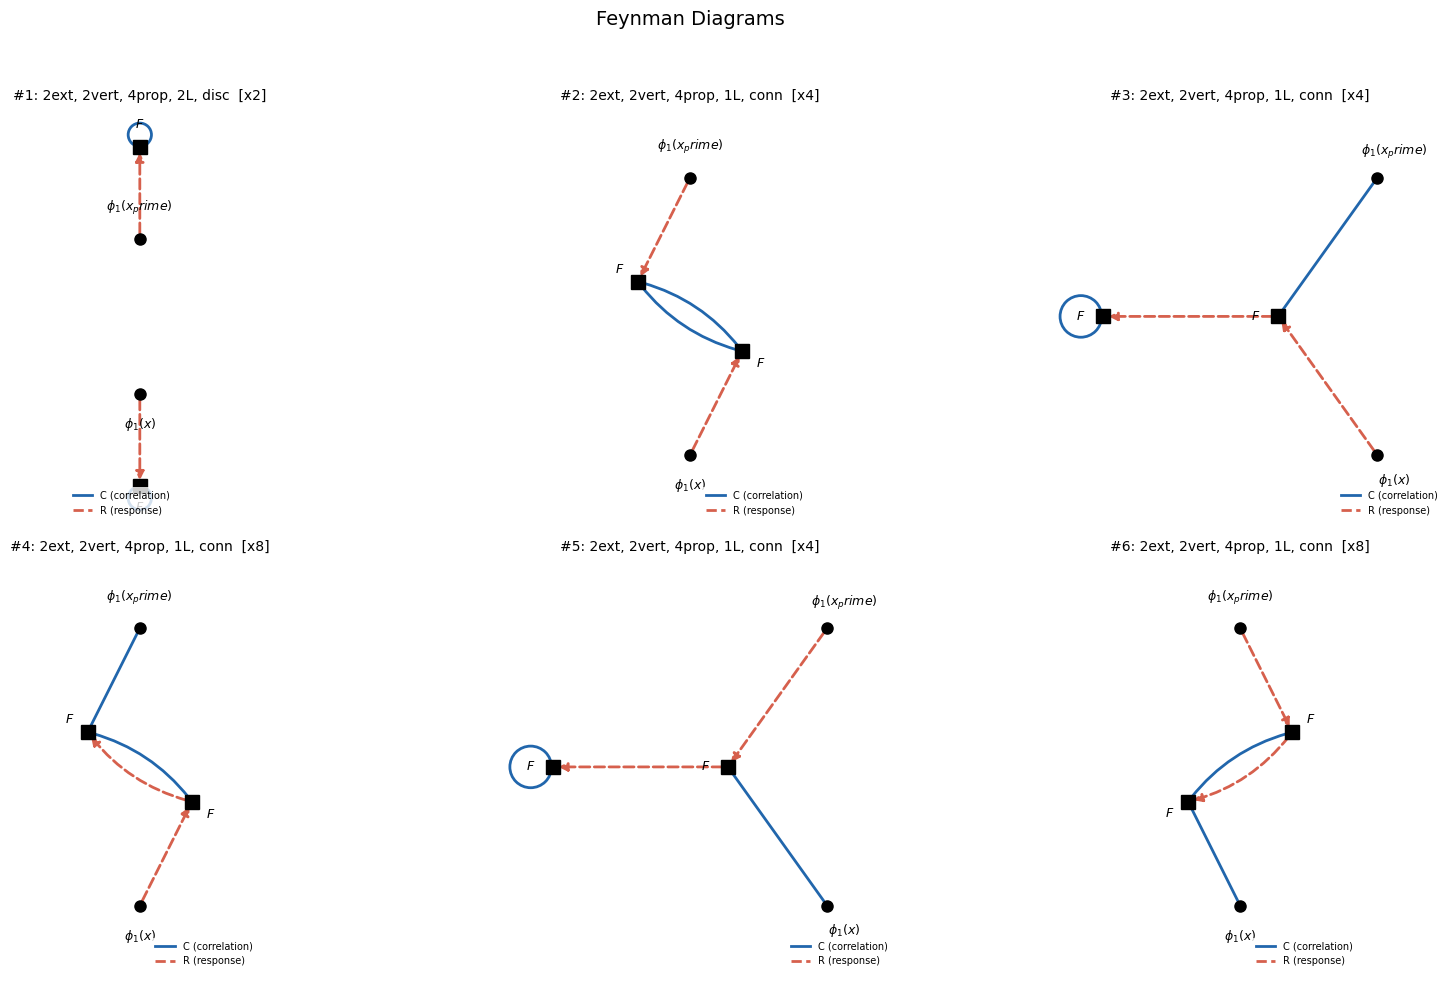

In [10]:
# Draw Feynman diagrams for order 2
result_corr.draw_diagrams(order=2)

In [11]:
# Evaluate all coupling arrays at order 2
print("Numerical coupling evaluation (order 2):\n")

for i, dt in enumerate(dts):
    coupling_array = dt.evaluate_coupling({'F': F_code})
    total = np.sum(coupling_array)
    n_nonzero = np.count_nonzero(coupling_array)
    phase = dt.response_phase_factor()
    
    print(f"Diagram {i}: shape={coupling_array.shape}, "
          f"nonzero={n_nonzero}, sum={total:+.4f}, phase={phase}")

Numerical coupling evaluation (order 2):

Diagram 0: shape=(3, 3, 3, 3, 3, 3), nonzero=25, sum=+42.2500, phase=-1.0
Diagram 1: shape=(3, 3, 3, 3, 3, 3), nonzero=35, sum=+42.2500, phase=-1.0
Diagram 2: shape=(3, 3, 3, 3, 3, 3), nonzero=35, sum=+42.2500, phase=-1.0
Diagram 3: shape=(3, 3, 3, 3, 3, 3), nonzero=49, sum=+84.5000, phase=-1.0
Diagram 4: shape=(3, 3, 3, 3, 3, 3), nonzero=35, sum=+42.2500, phase=-1.0
Diagram 5: shape=(3, 3, 3, 3, 3, 3), nonzero=35, sum=+42.2500, phase=-1.0
Diagram 6: shape=(3, 3, 3, 3, 3, 3), nonzero=49, sum=+84.5000, phase=-1.0
Diagram 7: shape=(3, 3, 3, 3, 3, 3), nonzero=49, sum=+84.5000, phase=-1.0
Diagram 8: shape=(3, 3, 3, 3, 3, 3), nonzero=35, sum=+42.2500, phase=-1.0
Diagram 9: shape=(3, 3, 3, 3, 3, 3), nonzero=49, sum=+84.5000, phase=-1.0
Diagram 10: shape=(3, 3, 3, 3, 3, 3), nonzero=35, sum=+42.2500, phase=-1.0


## 6. Propagator Setup

The free propagators are matrix-valued in component space:

$$R_{ab}(\mathbf{n}, t;\, \mathbf{n}', t') = \delta(\mathbf{n} - \mathbf{n}')\,\Theta(t-t')\, \bigl[\mathbf{Q}\,e^{\boldsymbol{\Lambda}\,\bar\chi(t,t')}\,\mathbf{Q}^T\bigr]_{ab}$$

$$C_{ab}(\mathbf{n}_1, \lambda_1;\, \mathbf{n}_2, \lambda_2) = \bigl[\mathbf{Q}\,\tilde{C}(\lambda_1, \lambda_2)\,\mathbf{Q}^T\bigr]_{ab}$$

where $\mathbf{M} = \mathbf{Q}\,\boldsymbol{\Lambda}\,\mathbf{Q}^T$ is the eigendecomposition of the coupling matrix

$$M_{ij} = F_{ij1} + F_{i1j}$$

In [12]:
# Coupling matrix: M_{ij} = F_{ij1} + F_{i1j}  (1-indexed, using physical F)
M = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        M[i, j] = F_physical[i, j, 0] + F_physical[i, 0, j]

print("Coupling matrix M:")
print(M)
print()

# Eigendecomposition: M = Q @ diag(eigenvalues) @ Q^T
eigenvalues, Q = np.linalg.eigh(M)  # eigh for symmetric matrices
Lambda = np.diag(eigenvalues)

print(f"Eigenvalues: {eigenvalues}")
print(f"\nQ (eigenvectors as columns):\n{Q}")
print(f"\nVerification: max|M - Q Lambda Q^T| = {np.max(np.abs(M - Q @ Lambda @ Q.T)):.2e}")

Coupling matrix M:
[[-1.  0.  0.]
 [ 0. -1.  0.]
 [ 0.  0. -1.]]

Eigenvalues: [-1. -1. -1.]

Q (eigenvectors as columns):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Verification: max|M - Q Lambda Q^T| = 0.00e+00


In [13]:
def R_propagator(chi_bar, a=None, b=None):
    """Response propagator matrix R(chi_bar).
    
    R = Theta(t-t') * Q @ exp(Lambda * chi_bar) @ Q^T
    
    Args:
        chi_bar: scalar time-dependent argument (e.g. integrated growth rate)
        a, b: optional component indices (0-indexed). If None, return full 3x3 matrix.
    
    Returns:
        R_{ab} or full matrix (Theta factor should be applied externally).
    """
    exp_Lambda = np.diag(np.exp(eigenvalues * chi_bar))
    R_mat = Q @ exp_Lambda @ Q.T
    if a is not None and b is not None:
        return R_mat[a, b]
    return R_mat


def C_propagator(chi_bar_1, chi_bar_2, C_tilde, a=None, b=None):
    """Correlation propagator matrix C.
    
    C = Q @ integral[exp(Lambda chi_bar_1') * C_tilde * exp(Lambda chi_bar_2')] @ Q^T
    
    This is a template — the double integral over chi_bar' depends on
    the specific time parametrisation and must be evaluated numerically.
    
    For demonstration, this evaluates at fixed chi_bar values:
    C = Q @ exp(Lambda * chi_bar_1) @ C_tilde @ exp(Lambda * chi_bar_2) @ Q^T
    
    Args:
        chi_bar_1, chi_bar_2: time arguments
        C_tilde: 3x3 cumulant matrix in eigenspace
        a, b: optional component indices
    """
    exp_L1 = np.diag(np.exp(eigenvalues * chi_bar_1))
    exp_L2 = np.diag(np.exp(eigenvalues * chi_bar_2))
    C_mat = Q @ exp_L1 @ C_tilde @ exp_L2 @ Q.T
    if a is not None and b is not None:
        return C_mat[a, b]
    return C_mat


# Quick test with chi_bar = 0.5
print("R(chi_bar=0.5):")
print(R_propagator(0.5))
print()

# C with identity cumulant
print("C(0.3, 0.4, C_tilde=I):")
print(C_propagator(0.3, 0.4, np.eye(3)))

R(chi_bar=0.5):
[[0.60653066 0.         0.        ]
 [0.         0.60653066 0.        ]
 [0.         0.         0.60653066]]

C(0.3, 0.4, C_tilde=I):
[[0.4965853 0.        0.       ]
 [0.        0.4965853 0.       ]
 [0.        0.        0.4965853]]


## 7. Full Numerical Evaluation: Putting It Together

For each `DiagramTerm`, the full contribution is:

$$\text{diagram value} = \text{prefactor} \times \text{phase} \times \sum_{\text{indices}} \text{coupling\_array}[\text{indices}] \times \prod_{\text{propagators}} P_{a_k b_k}(x_k, x'_k)$$

integrated over `integration_vars`.

Below we demonstrate this for order 1 of $\langle\phi_1(x)\rangle$, where there is a single diagram:
$$\sum_{i_0, i_1, i_2} F_{i_0 i_1 i_2}\, R_{1\, i_0}(x, y_0)\, C_{i_1 i_2}(y_0, y_0) \int \mathrm{d}y_0$$

In [14]:
def evaluate_diagram_integrand(dt, coupling_values, prop_funcs, spatial_args):
    """Evaluate a DiagramTerm's integrand at specific spatial points.
    
    Args:
        dt: DiagramTerm object
        coupling_values: dict of coupling arrays, e.g. {'F': F_code}
        prop_funcs: dict mapping (kind, spatial_left, spatial_right) to a function
                    that returns the propagator matrix (3x3) at those spatial points
        spatial_args: dict mapping spatial variable names to their values
    
    Returns:
        Scalar value: sum over component indices of (coupling × propagators)
    """
    coupling_array = dt.evaluate_coupling(coupling_values)
    # coupling_array shape = (dim_0, dim_1, ...) matching summation_indices
    
    idx_names = [name for name, _ in dt.summation_indices]
    dims = [dim for _, dim in dt.summation_indices]
    
    # External index '1' → 0-indexed is 0
    external_map = {'1': 0}  
    
    total = 0.0
    for multi_idx in np.ndindex(*dims) if dims else [()]:
        # Map index names to values
        idx_map = {name: val for name, val in zip(idx_names, multi_idx)}
        idx_map.update(external_map)
        
        # Get coupling value at this index combination
        c_val = coupling_array[multi_idx] if dims else float(coupling_array)
        if c_val == 0:
            continue
        
        # Multiply propagator values
        prop_product = 1.0
        for p in dt.propagators:
            # Get component indices (0-indexed)
            a = idx_map.get(p.index_left, int(p.index_left) - 1 if p.index_left and p.index_left.isdigit() else None)
            b = idx_map.get(p.index_right, int(p.index_right) - 1 if p.index_right and p.index_right.isdigit() else None)
            
            # Look up propagator function
            key = (p.kind, p.spatial_left, p.spatial_right)
            prop_val = prop_funcs[key](a, b)
            prop_product *= prop_val
        
        total += c_val * prop_product
    
    return total

In [15]:
# Example: evaluate order 1 of <phi_1(x)> at a specific spatial configuration
# 
# The diagram has: R_{1, i_0}(x, y_0)  C_{i_1, i_2}(y_0, y_0)
# At a fixed integration point y_0, with chi_bar(x, y_0) = 0.5

dt = result_mean.diagram_terms(1)[0]
print(f"Diagram topology: {dt.spatial_topology()}")
print(f"Propagators: {[p.to_latex() for p in dt.propagators]}")
print()

# Define propagator functions for this spatial configuration
chi_bar_x_y0 = 0.5  # R(x, y_0): chi_bar between x and y_0
C_tilde = np.eye(3)  # placeholder cumulant

R_mat_x_y0 = R_propagator(chi_bar_x_y0)
C_mat_y0_y0 = C_propagator(0.0, 0.0, C_tilde)  # C(y_0, y_0): equal-point

print(f"R(x, y_0) matrix:\n{R_mat_x_y0}\n")
print(f"C(y_0, y_0) matrix:\n{C_mat_y0_y0}\n")

# Build propagator lookup
prop_funcs = {
    ('R', 'x', 'y_0'): lambda a, b: R_mat_x_y0[a, b],
    ('C', 'y_0', 'y_0'): lambda a, b: C_mat_y0_y0[a, b],
}

integrand = evaluate_diagram_integrand(dt, {'F': F_code}, prop_funcs, {})
phase = dt.response_phase_factor()

print(f"Integrand value (before integration over y_0): {integrand:+.6f}")
print(f"Phase factor (-i)^{dt.n_response}: {phase}")
print(f"Physical contribution: {integrand * phase}")

Diagram topology: [('R', 'x', 'y_0'), ('C', 'y_0', 'y_0')]
Propagators: ['R_{1i_{0}}(x, y_{0})', 'C_{i_{1}i_{2}}(y_{0}, y_{0})']

R(x, y_0) matrix:
[[0.60653066 0.         0.        ]
 [0.         0.60653066 0.        ]
 [0.         0.         0.60653066]]

C(y_0, y_0) matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Integrand value (before integration over y_0): -2.729388
Phase factor (-i)^1: (-0-1j)
Physical contribution: 2.7293879687068503j


## 8. Higher Orders

The spatial-level engine makes higher-order computations feasible by enumerating spatial topologies instead of individual pairings.

In [16]:
import time

# <phi_1(x)> up to order 5
reset_uid_counter()
obs = [phi('1', 'x')]

t0 = time.time()
result_o5 = compute_moment(obs, action, order=5, response_phase=False)
elapsed = time.time() - t0

print(f"Computed <phi_1(x)> to order 5 in {elapsed:.2f}s\n")

for n in range(6):
    dts = result_o5.diagram_terms(n)
    expr = result_o5.order(n)
    is_zero = hasattr(expr, 'is_zero') and expr.is_zero
    if is_zero:
        print(f"  Order {n}: 0  (vanishes)")
    else:
        print(f"  Order {n}: {len(dts)} diagram(s), LaTeX length = {len(expr.to_latex())}")

Computed <phi_1(x)> to order 5 in 3.95s

  Order 0: 0  (vanishes)
  Order 1: 1 diagram(s), LaTeX length = 152
  Order 2: 0  (vanishes)
  Order 3: 18 diagram(s), LaTeX length = 8543
  Order 4: 0  (vanishes)


  Order 5: 2744 diagram(s), LaTeX length = 8753678


In [17]:
# Quick numerical check: evaluate all coupling arrays at order 3
print("Order 3 coupling evaluation:\n")
for i, dt in enumerate(result_o5.diagram_terms(3)):
    arr = dt.evaluate_coupling({'F': F_code})
    total = np.sum(arr)
    print(f"  Diagram {i}: {len(dt.propagators)} propagators, "
          f"coupling sum = {total:+.4f}, "
          f"topology = {dt.spatial_topology()}")

Order 3 coupling evaluation:

  Diagram 0: 5 propagators, coupling sum = -91.5417, topology = [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_0', 'y_2'), ('C', 'y_1', 'y_1'), ('C', 'y_2', 'y_2')]


  Diagram 1: 5 propagators, coupling sum = -183.0833, topology = [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_0', 'y_2'), ('C', 'y_1', 'y_2'), ('C', 'y_1', 'y_2')]


  Diagram 2: 5 propagators, coupling sum = -183.0833, topology = [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_1', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_2', 'y_2')]


  Diagram 3: 5 propagators, coupling sum = -366.1667, topology = [('R', 'x', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'y_1', 'y_2'), ('C', 'y_0', 'y_2'), ('C', 'y_1', 'y_2')]


  Diagram 4: 5 propagators, coupling sum = -366.1667, topology = [('R', 'x', 'y_0'), ('R', 'y_2', 'y_1'), ('R', 'y_0', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_1', 'y_2')]
  Diagram 5: 5 propagators, coupling sum = -183.0833, topology = [('R', 'x', 'y_0'), ('R', 'y_2', 'y_1'), ('R', 'y_0', 'y_2'), ('C', 'y_0', 'y_2'), ('C', 'y_1', 'y_1')]


...

  Diagram 9: 5 propagators, coupling sum = -183.0833, topology = [('R', 'y_1', 'y_0'), ('R', 'x', 'y_1'), ('R', 'y_1', 'y_2'), ('C', 'y_0', 'y_2'), ('C', 'y_0', 'y_2')]
  Diagram 10: 5 propagators, coupling sum = -183.0833, topology = [('R', 'y_1', 'y_0'), ('R', 'y_2', 'y_1'), ('R', 'x', 'y_2'), ('C', 'y_0', 'y_0'), ('C', 'y_1', 'y_2')]


  Diagram 11: 5 propagators, coupling sum = -366.1667, topology = [('R', 'y_1', 'y_0'), ('R', 'y_2', 'y_1'), ('R', 'x', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_0', 'y_2')]
  Diagram 12: 5 propagators, coupling sum = -183.0833, topology = [('R', 'y_2', 'y_0'), ('R', 'x', 'y_1'), ('R', 'y_1', 'y_2'), ('C', 'y_0', 'y_0'), ('C', 'y_1', 'y_2')]


  Diagram 13: 5 propagators, coupling sum = -366.1667, topology = [('R', 'y_2', 'y_0'), ('R', 'x', 'y_1'), ('R', 'y_1', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_0', 'y_2')]


  Diagram 14: 5 propagators, coupling sum = -366.1667, topology = [('R', 'y_2', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'x', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_1', 'y_2')]
  Diagram 15: 5 propagators, coupling sum = -183.0833, topology = [('R', 'y_2', 'y_0'), ('R', 'y_0', 'y_1'), ('R', 'x', 'y_2'), ('C', 'y_0', 'y_2'), ('C', 'y_1', 'y_1')]


  Diagram 16: 5 propagators, coupling sum = -91.5417, topology = [('R', 'y_2', 'y_0'), ('R', 'y_2', 'y_1'), ('R', 'x', 'y_2'), ('C', 'y_0', 'y_0'), ('C', 'y_1', 'y_1')]
  Diagram 17: 5 propagators, coupling sum = -183.0833, topology = [('R', 'y_2', 'y_0'), ('R', 'y_2', 'y_1'), ('R', 'x', 'y_2'), ('C', 'y_0', 'y_1'), ('C', 'y_0', 'y_1')]


## 9. Custom LaTeX Formatting

In [18]:
# Custom propagator names
fmt = LaTeXFormatter(propagator_names={
    'C': r'P',
    'R': r'g'
})

display(Math(r"\langle \phi_1(x) \rangle^{(1)} = " + fmt.format(result_mean.order(1))))

# LaTeX align environment for order-by-order display
print("\nLaTeX source for aligned display:")
print(fmt.format_aligned(result_mean.order_terms))

<IPython.core.display.Math object>


LaTeX source for aligned display:
\begin{align}
  O(0) &= 0 \\
  O(1) &= \sum_{i_{2}=1}^{3} \sum_{i_{1}=1}^{3} \sum_{i_{0}=1}^{3} \int \mathrm{d}y_{0}\, -1 F_{i_{0}i_{1}i_{2}} g_{1i_{0}}(x, y_{0}) P_{i_{1}i_{2}}(y_{0}, y_{0}) \\
  O(2) &= 0 \\
  O(3) &= \sum_{i_{8}=1}^{3} \sum_{i_{7}=1}^{3} \sum_{i_{6}=1}^{3} \sum_{i_{5}=1}^{3} \sum_{i_{4}=1}^{3} \sum_{i_{3}=1}^{3} \sum_{i_{2}=1}^{3} \sum_{i_{1}=1}^{3} \sum_{i_{0}=1}^{3} \int \mathrm{d}y_{2}\, \int \mathrm{d}y_{1}\, \int \mathrm{d}y_{0}\, -\frac{1}{6} \left(\left(F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} F_{i_{6}i_{7}i_{8}} + F_{i_{0}i_{2}i_{1}} F_{i_{3}i_{4}i_{5}} F_{i_{6}i_{7}i_{8}}\right) g_{1i_{0}}(x, y_{0}) g_{i_{1}i_{3}}(y_{0}, y_{1}) g_{i_{2}i_{6}}(y_{0}, y_{2}) P_{i_{4}i_{5}}(y_{1}, y_{1}) P_{i_{7}i_{8}}(y_{2}, y_{2}) + \left(F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} F_{i_{6}i_{7}i_{8}} + F_{i_{0}i_{1}i_{2}} F_{i_{3}i_{4}i_{5}} F_{i_{6}i_{8}i_{7}} + F_{i_{0}i_{2}i_{1}} F_{i_{3}i_{4}i_{5}} F_{i_{6}i_{7}i_{8}} + F_{i_{0}i_{2}i_{1}} 